In [273]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error, root_mean_squared_error

# improving from baseline
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

TARGET = "ClosePrice"

In [274]:
train_df = pd.read_parquet("../data/train_preprocessed.parquet")
test_df = pd.read_parquet("../data/test_preprocessed.parquet")

print("Train shape (1 year before test month):", train_df.shape)
print("Test shape  (test month):", test_df.shape)

Train shape (1 year before test month): (81857, 30)
Test shape  (test month): (7442, 30)


# Model 1: Linear Regression (Numerical Features Only)

In [294]:
NON_FEATURE_COLS = ["CloseDate", "ListingKey", "CloseMonth"]
def build_X_y(frame):
    X = frame.drop(columns=[c for c in [TARGET] + NON_FEATURE_COLS if c in frame.columns])
    X = X.select_dtypes(include=[np.number])
    y = frame[TARGET]
    return X, y

X_train, y_train = build_X_y(train_df)
X_test, y_test = build_X_y(test_df)

print(f"{X_train.shape[1]} features:", list(X_train.columns))

21 features: ['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'NewConstructionYN', 'GarageSpaces', 'LotSizeSquareFeet', 'HasNamedSubdivision', 'Level_One', 'Level_Two', 'Level_ThreeOrMore', 'Level_MultiSplit']


Train numeric features only linear regression model

In [295]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model 1 Metrics

In [296]:
# model evaluator for efficiency
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    return {
        "model": name,
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred),
        "test_rmse": root_mean_squared_error(y_test, test_pred),
        "test_mape": mean_absolute_percentage_error(y_test, test_pred),
    }

In [297]:
results = [evaluate_model(model, X_train, y_train, X_test, y_test, "Lin Regression (baseline)")]
pd.DataFrame(results).round(4)

,model,train_r2,test_r2,test_rmse,test_mape
0,Lin Regression (baseline),0.5116,0.5172,547680.346,0.3687


---
# Model 2: Linear Regression with Numerical and Encoded Categorical Features

In [298]:
CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor", "HighSchoolDistrict", "Levels"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
encoder.fit(train_df[CATEGORICAL_COLS])

def build_X_y(frame):
    numeric_part = frame.drop(columns=[c for c in [TARGET] + NON_FEATURE_COLS + CATEGORICAL_COLS if c in frame.columns])
    numeric_part = numeric_part.select_dtypes(include=[np.number])
    encoded = encoder.transform(frame[CATEGORICAL_COLS])
    X = hstack([csr_matrix(numeric_part.values), encoded]).tocsr()
    y = frame[TARGET].values
    feature_names = list(numeric_part.columns) + list(encoder.get_feature_names_out(CATEGORICAL_COLS))
    return X, y, feature_names

X_train2, y_train2, feature_names = build_X_y(train_df)
X_test2, y_test2, _ = build_X_y(test_df)


print(f"{X_train2.shape[1]} features")

3282 features


In [299]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [300]:
results.append(evaluate_model(model2, X_train2, y_train2, X_test2, y_test2, "Lin Reg (Numeric + Categorical Encoded Variables)"))
pd.DataFrame(results).round(4)

,model,train_r2,test_r2,test_rmse,test_mape
0,Lin Regression (baseline),0.5116,0.5172,547680.3460,0.3687
1,Lin Reg (Numeric + Categorical Encoded Variables),0.8534,0.8420,313321.9877,0.1904


### Model 2 Performance Analysis

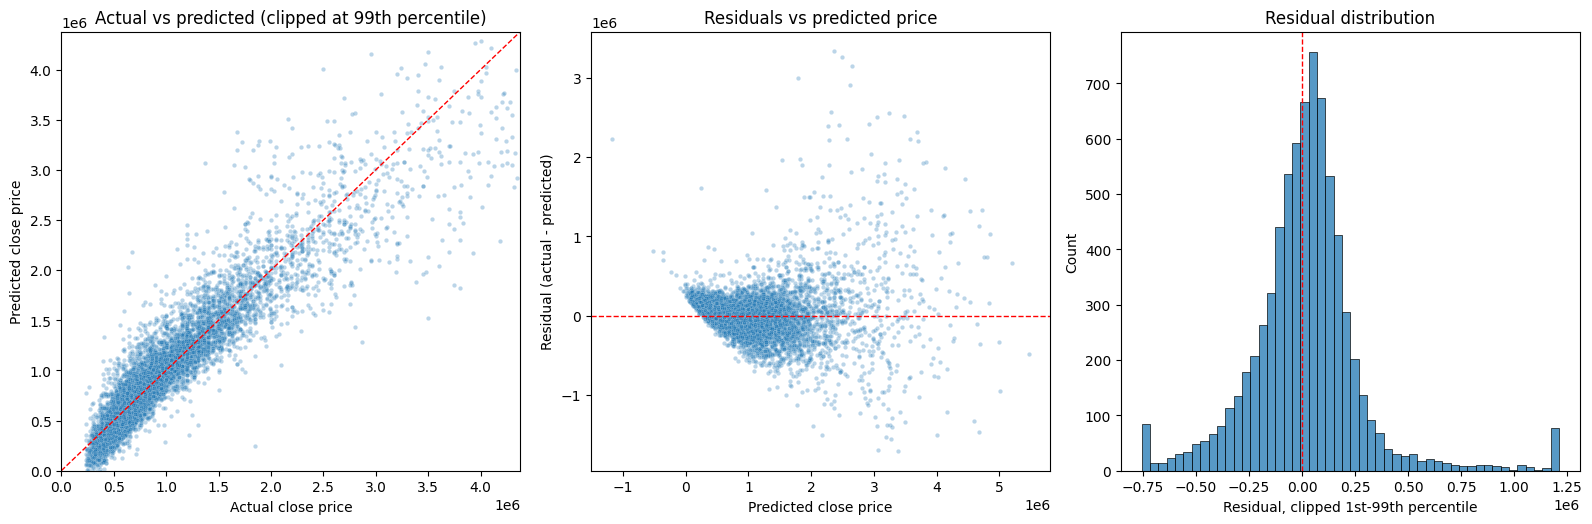

In [301]:
fig, axes = plt.subplots(1, 3, figsize=(16 ,5.5))

train_pred2 = model2.predict(X_train2)
test_pred2 = model2.predict(X_test2)

r2_train2 = results[1]['train_r2']
r2_test2 = results[1]['test_r2']
mape_test2 = results[1]['test_mape']
rmse_test2 = results[1]['test_rmse']

# Actual vs. Predicted
max_price = np.percentile(y_test, 99)
sns.scatterplot(x=y_test, y=test_pred2, s=10, alpha=0.3, ax=axes[0])
axes[0].plot([0, max_price], [0, max_price], color="red", linestyle="--", linewidth=1)
axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual close price")
axes[0].set_ylabel("Predicted close price")
axes[0].set_title("Actual vs predicted (clipped at 99th percentile)")

# Residuals vs. Predicted
residuals = y_test2 - test_pred2
sns.scatterplot(x=test_pred2, y=residuals, s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted close price")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs predicted price")

# Residual distribution
clipped = residuals.clip(np.quantile(residuals, 0.01), np.quantile(residuals, 0.99))
sns.histplot(clipped, bins=50, ax=axes[2])
axes[2].axvline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_xlabel("Residual, clipped 1st-99th percentile")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

In [302]:
# check model performance on train and test sets
def regression_summary(y_true, y_pred, label):
    ape = (np.abs(y_true - y_pred) / y_true) * 100
    return {"split": label, "r2": r2_score(y_true, y_pred),
            "rmse": root_mean_squared_error(y_true, y_pred),
            "mape": ape.mean(), "mdape": np.median(ape)}

summary_df = pd.DataFrame([
    regression_summary(y_train2, train_pred2, "train"),
    regression_summary(y_test2, test_pred2, "test"),
]).set_index("split").round(4)
display(summary_df.reset_index())

,split,r2,rmse,mape,mdape
0,train,0.8534,291979.2633,18.5127,13.4459
1,test,0.8420,313321.9877,19.0417,13.3753


In [303]:
# error by price band
error_df = pd.DataFrame({"actual": y_test2, "predicted": test_pred2})
error_df["abs_pct_error"] = (error_df["actual"] - error_df["predicted"]).abs() / error_df["actual"] * 100
error_df["price_band"] = pd.qcut(error_df["actual"], q=5,
    labels=["Lowest 20%", "Low-mid", "Mid", "Mid-high", "Highest 20%"])

price_band_summary = error_df.groupby("price_band", observed=True).agg(
    n=("actual", "size"),
    mean_actual=("actual", "mean"),
    mape=("abs_pct_error", "mean"),
    mdape=("abs_pct_error", "median"),
).round(2)
display(price_band_summary.reset_index())

,price_band,n,mean_actual,mape,mdape
0,Lowest 20%,1517,434317.17,29.61,22.91
1,Low-mid,1488,652757.06,20.69,15.58
2,Mid,1464,862151.56,15.54,11.48
3,Mid-high,1489,1204135.51,13.98,10.21
4,Highest 20%,1484,2324866.32,15.12,12.18


In [304]:
# error by MLS area
error_df["MLSAreaMajor"] = test_df["MLSAreaMajor"].values

county_summary = (
    error_df.groupby("MLSAreaMajor", observed=True)
    .agg(n=("actual", "size"), mape=("abs_pct_error", "mean"))
    .query("n >= 30")
    .sort_values("mape", ascending=False)
)
print("Worst-performing counties:"); display(county_summary.head(10))
print("Best-performing counties:"); display(county_summary.tail(10))

Worst-performing counties:


,n,mape
MLSAreaMajor,,
313 - La Quinta South of HWY 111,53,36.139200
HSP - Hesperia,78,34.323279
APPV - Apple Valley,76,31.799624
309 - Indio North of East Valley,42,29.649934
263 - Banning/Beaumont/Cherry Valley,98,28.744931
LAC - Lancaster,99,27.378920
Unknown,604,26.502849
VIC - Victorville,105,25.590565
BKSF - Bakersfield,48,25.321726


Best-performing counties:


,n,mape
MLSAreaMajor,,
686 - Ontario,56,13.658044
605 - Arcadia,31,13.643463
688 - Rancho Cucamonga,58,13.576453
16 - Fountain Valley / Northeast HB,33,13.459736
690 - Upland,36,13.107693
669 - West Covina,39,12.337414
WHLL - Woodland Hills,30,12.103503
"75 - Orange, Orange Park Acres E of 55",30,9.120154
682 - Chino Hills,37,8.495260


Why are we seeing significant error in differing areas:

---
# Model 3: Linear Regression with Numerical and Encoded Categorical Data, collapsed rare MLSAreaMajor entries
#### Accounting for Low Train and Test populations of rare MLSAreaMajors

In [305]:
MIN_CATEGORY_COUNT = 4
area_counts = train_df["MLSAreaMajor"].value_counts()
rare_areas = area_counts[area_counts < MIN_CATEGORY_COUNT].index

train_df["MLSAreaMajor"] = train_df["MLSAreaMajor"].where(~train_df["MLSAreaMajor"].isin(rare_areas), "Other")
test_df["MLSAreaMajor"] = test_df["MLSAreaMajor"].where(~test_df["MLSAreaMajor"].isin(rare_areas), "Other")

print(f"Collapsed {len(rare_areas)} rare categories into 'Other'")

Collapsed 0 rare categories into 'Other'


In [306]:
CATEGORICAL_COLS = ["City", "PostalCode", "MLSAreaMajor", "HighSchoolDistrict", "Levels"]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
encoder.fit(train_df[CATEGORICAL_COLS])

def build_X_y(frame):
    numeric_part = frame.drop(columns=[c for c in [TARGET] + NON_FEATURE_COLS + CATEGORICAL_COLS if c in frame.columns])
    numeric_part = numeric_part.select_dtypes(include=[np.number])
    encoded = encoder.transform(frame[CATEGORICAL_COLS])
    X = hstack([csr_matrix(numeric_part.values), encoded]).tocsr()
    y = frame[TARGET].values
    feature_names = list(numeric_part.columns) + list(encoder.get_feature_names_out(CATEGORICAL_COLS))
    return X, y, feature_names

X_train3, y_train3, feature_names = build_X_y(train_df)
X_test3, y_test3, _ = build_X_y(test_df)


print(f"{X_train2.shape[1]} features")

3282 features


In [307]:
model3 = LinearRegression()
model3.fit(X_train3, y_train3)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [308]:
results.append(evaluate_model(model3, X_train3, y_train3, X_test3, y_test3, "Lin Reg (Num + Cat w/ Collapsed MLS)"))
comparison_df = pd.DataFrame(results).round(4)

---
# All Model Comparisons

In [309]:
comparison_df

,model,train_r2,test_r2,test_rmse,test_mape
0,Lin Regression (baseline),0.5116,0.5172,547680.3460,0.3687
1,Lin Reg (Numeric + Categorical Encoded Variables),0.8534,0.8420,313321.9877,0.1904
2,Lin Reg (Num + Cat w/ Collapsed MLS),0.8534,0.8420,313321.9877,0.1904


Will choose Linear Regression (with Numerical and Categorical Encoded Variables and Collapsed rare MLSAreaMajor entries) due to the slightly better performance after collapsing the rare MLSAreaMajor entries. This will be our new baseline to improve upon.

In [293]:
# output model
joblib.dump({
    "X_train": X_train3, "X_test": X_test3,
    "y_train": y_train3, "y_test": y_test3,
    "feature_names": feature_names,
    "encoder": encoder,
    "linear_model": model3,
}, "../data/baseline_artifacts.joblib")

print("Saved feature matrices, encoder, and fitted linear model for reuse in 04_model_comparison.ipynb")

Saved feature matrices, encoder, and fitted linear model for reuse in 04_model_comparison.ipynb
